# Trening segmentacji CARLA short (`train1`)

**Dane:** `CARLA_short_processed` (13 klas po merge). **Podział:** train `00`–`15`, val `16`–`17`, test `18`–`19`.

**Model:** ResNet34 + dekoder, enkoder **trenowalny** (`freeze_encoder=False`), start wag z `../src_long/unfreeze_encoder_fullset_411.ckpt`. Uruchamiaj komórki po kolei od góry.

In [1]:
import glob
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset

import pytorch_lightning as pl
from pytorch_lightning import Trainer
import torchvision.models as models
import torchvision.transforms as T

# --- Konfiguracja (ścieżki względem katalogu, w którym leży ten notebook) ---
CONFIG = {
    "data_root": "../CARLA_short_processed",
    "max_images_per_sequence": None,  # np. 40 dla szybkich testów; None = wszystkie
    "batch_size": 4,
    "num_workers": 2,
    "train_sequences": [f"{i:02d}" for i in range(16)],   # 00–15
    "val_sequences": [f"{i:02d}" for i in range(16, 18)],  # 16–17
    "test_sequences": [f"{i:02d}" for i in range(18, 20)],  # 18–19
    "epochs": 10,
    "lr": 1e-4,
    "loss_ignore_index": 0,
    "freeze_encoder": False,
    "pretrained_checkpoint": "../src_long/unfreeze_encoder_fullset_411.ckpt",
    "checkpoint_path": "train1_short_unfreeze_finetune.ckpt",
    "seed": 42,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])


In [2]:
def build_label_lut(class_map: dict, size: int = 256) -> np.ndarray:
    lut = np.zeros(size, dtype=np.int64)
    for raw, idx in class_map.items():
        lut[int(raw)] = int(idx)
    return lut


# 13 klas po merge (jak train_long.ipynb) — raw id 0–12 = indeks klasy
NUM_CLASSES = 13
class_map = {i: i for i in range(NUM_CLASSES)}
LABEL_LUT = build_label_lut(class_map)
print("NUM_CLASSES =", NUM_CLASSES)


NUM_CLASSES = 13


In [3]:
class CARLADataset(Dataset):
    def __init__(
        self,
        root: str,
        label_lut: np.ndarray,
        max_per_sequence: int | None = None,
        sequences: list[str] | None = None,
    ):
        self.samples = []
        self.label_lut = label_lut

        all_folders = sorted(
            f for f in os.listdir(root)
            if os.path.isdir(os.path.join(root, f)) and f.isdigit()
        )
        if sequences is not None:
            seq_set = set(sequences)
            all_folders = [f for f in all_folders if f in seq_set]

        for folder in all_folders:
            rgb_dir = os.path.join(root, folder, "rgb")
            mask_dir = os.path.join(root, folder, "segmentation_raw")
            if not os.path.isdir(rgb_dir) or not os.path.isdir(mask_dir):
                continue

            img_paths = sorted(glob.glob(os.path.join(rgb_dir, "*.png")))
            if max_per_sequence is not None:
                img_paths = img_paths[:max_per_sequence]

            for img_path in img_paths:
                name = os.path.basename(img_path)
                mask_path = os.path.join(mask_dir, name)
                if os.path.exists(mask_path):
                    self.samples.append((img_path, mask_path))

        self.img_tf = T.Compose([T.ToTensor()])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))[:, :, 0]
        mask = self.label_lut[mask.astype(np.int64)]
        mask = torch.from_numpy(mask).long()
        img = self.img_tf(img)
        return img, mask


In [4]:
class SegModel(nn.Module):
    def __init__(self, num_classes: int, freeze_encoder: bool = False):
        super().__init__()
        self.freeze_encoder = freeze_encoder
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.encoder = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(16, num_classes, 1),
        )
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def train(self, mode: bool = True):
        super().train(mode)
        if self.freeze_encoder:
            self.encoder.eval()
        return self

    def forward(self, x):
        return self.decoder(self.encoder(x))


def load_seg_weights_from_checkpoint(model: nn.Module, ckpt_path: str, device: torch.device) -> None:
    path = os.path.abspath(ckpt_path)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Brak checkpointu: {path}")
    ckpt = torch.load(path, map_location=device)
    sd = {
        k.replace("model.", "", 1): v
        for k, v in ckpt["state_dict"].items()
        if k.startswith("model.")
    }
    model.load_state_dict(sd, strict=True)
    print(f"Wczytano wagi z: {path}")


class LitSegModel(pl.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 1e-4, ignore_index: int = 0):
        super().__init__()
        self.model = model
        self.lr = lr
        self.ignore_index = ignore_index
        self.criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, masks = batch
        preds = self(imgs)
        preds = F.interpolate(
            preds,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return self.criterion(preds, masks)

    def training_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._step(batch)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        trainable = (p for p in self.model.parameters() if p.requires_grad)
        return torch.optim.Adam(trainable, lr=self.lr)


In [5]:
# Dataset, split po sekwencjach, modele, trening
root = CONFIG["data_root"]
_ds_kw = dict(
    label_lut=LABEL_LUT,
    max_per_sequence=CONFIG["max_images_per_sequence"],
)

train_ds = CARLADataset(root, sequences=CONFIG["train_sequences"], **_ds_kw)
val_ds = CARLADataset(root, sequences=CONFIG["val_sequences"], **_ds_kw)
test_ds = CARLADataset(root, sequences=CONFIG["test_sequences"], **_ds_kw)

train_n, val_n, test_n = len(train_ds), len(val_ds), len(test_ds)
n = train_n + val_n + test_n
if n == 0:
    raise RuntimeError(
        "Brak próbek — sprawdź data_root i strukturę folderów (np. 00/rgb, 00/segmentation_raw)."
    )
if train_n == 0:
    raise RuntimeError("Brak próbek w train — sprawdź train_sequences i data_root.")
if val_n == 0:
    raise RuntimeError("Brak próbek w val — sprawdź val_sequences (16, 17) i data_root.")
if test_n == 0:
    raise RuntimeError("Brak próbek w test — sprawdź test_sequences (18, 19) i data_root.")

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)
test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print(
    f"Dataset: {n} próbek (sekwencje train={CONFIG['train_sequences']}, "
    f"val={CONFIG['val_sequences']}, test={CONFIG['test_sequences']}) "
    f"→ train={train_n}, val={val_n}, test={test_n} "
    f"({len(train_loader)} / {len(val_loader)} / {len(test_loader)} batchy)"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model = SegModel(
    num_classes=NUM_CLASSES,
    freeze_encoder=CONFIG["freeze_encoder"],
).to(device)
load_seg_weights_from_checkpoint(
    torch_model,
    CONFIG["pretrained_checkpoint"],
    device,
)
_n_trainable = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)
print(
    f"Enkoder: {'zamrożony' if CONFIG['freeze_encoder'] else 'trenowalny'} "
    f"({_n_trainable:,} parametrów do optymalizacji)"
)
lit_model = LitSegModel(
    torch_model,
    lr=CONFIG["lr"],
    ignore_index=CONFIG["loss_ignore_index"],
)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
trainer = Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator=accelerator,
    devices=1,
)

trainer.fit(lit_model, train_loader, val_loader)
trainer.save_checkpoint(CONFIG["checkpoint_path"])
print("Zapisano:", CONFIG["checkpoint_path"])


Dataset: 3800 próbek (sekwencje train=['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15'], val=['16', '17'], test=['18', '19']) → train=3000, val=400, test=400 (750 / 100 / 100 batchy)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/jaklap/ZSN/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs

Wczytano wagi z: /home/jaklap/ZSN/Projekt_segmentacja/repo/ZSN_Projekt/src_long/unfreeze_encoder_fullset_411.ckpt
Enkoder: trenowalny (21,983,757 parametrów do optymalizacji)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jaklap/ZSN/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
`weights_only` was not set, defaulting to `False`.


Zapisano: train1_short_unfreeze_finetune.ckpt


Wczytano wagi z: /home/jaklap/ZSN/Projekt_segmentacja/repo/ZSN_Projekt/source/train1_short_unfreeze_finetune.ckpt


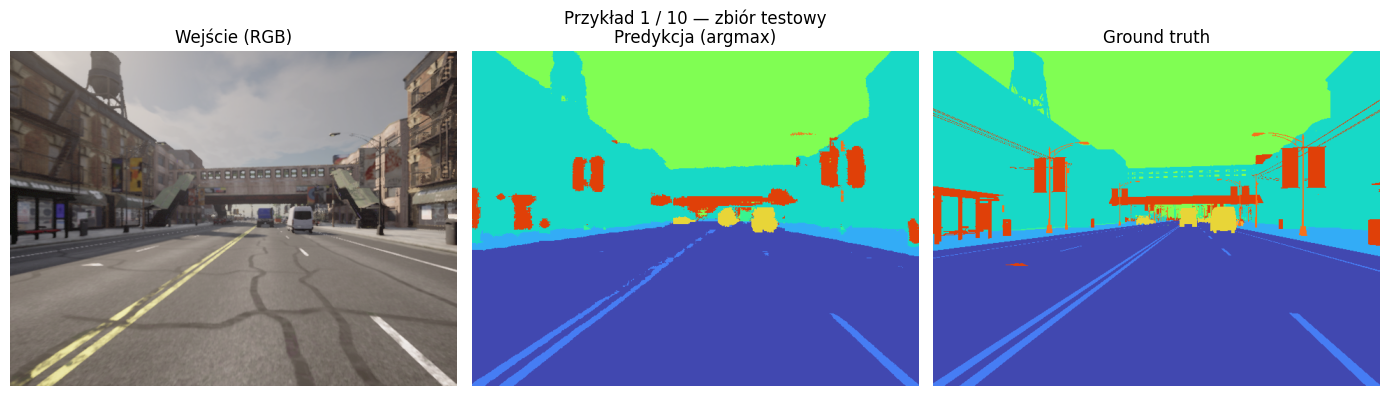

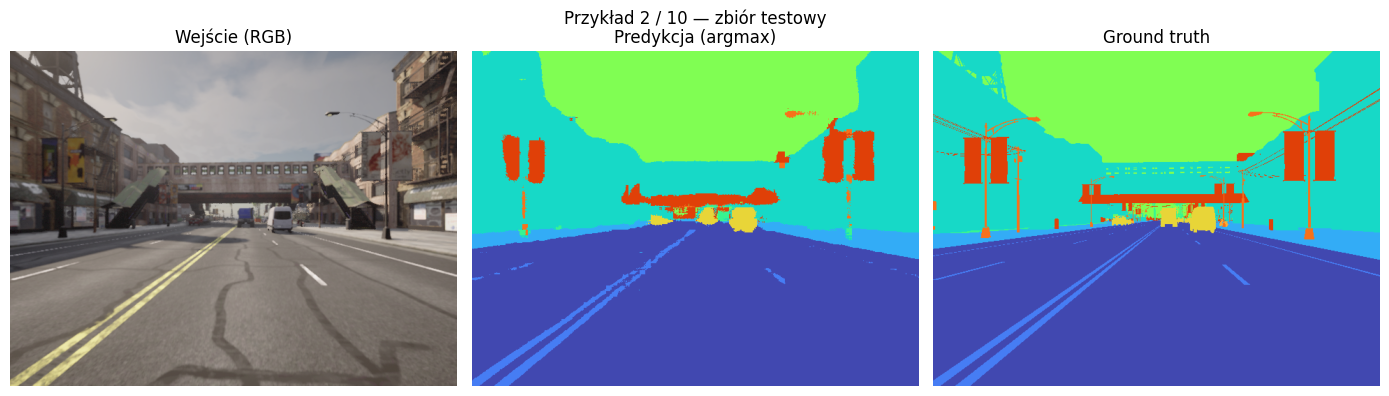

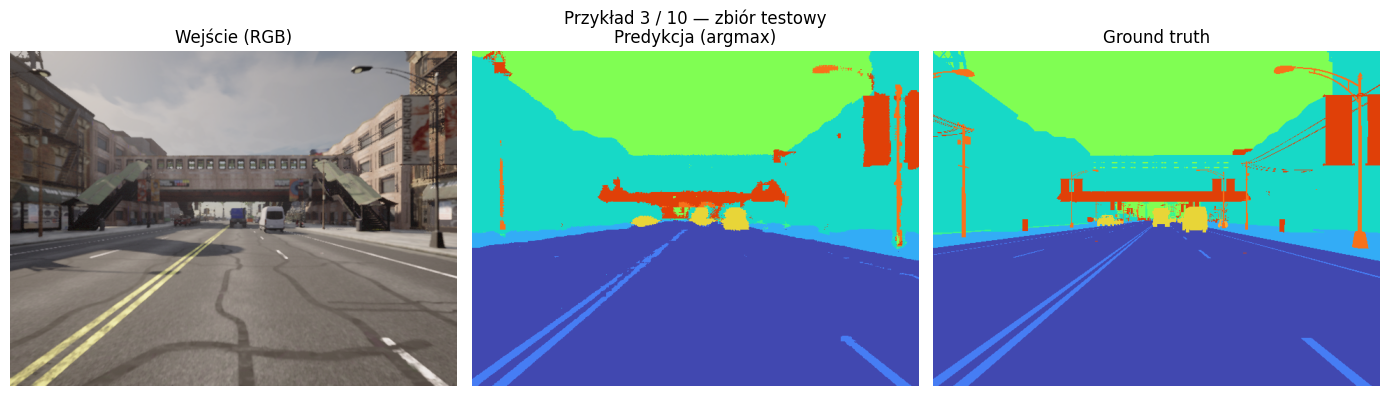

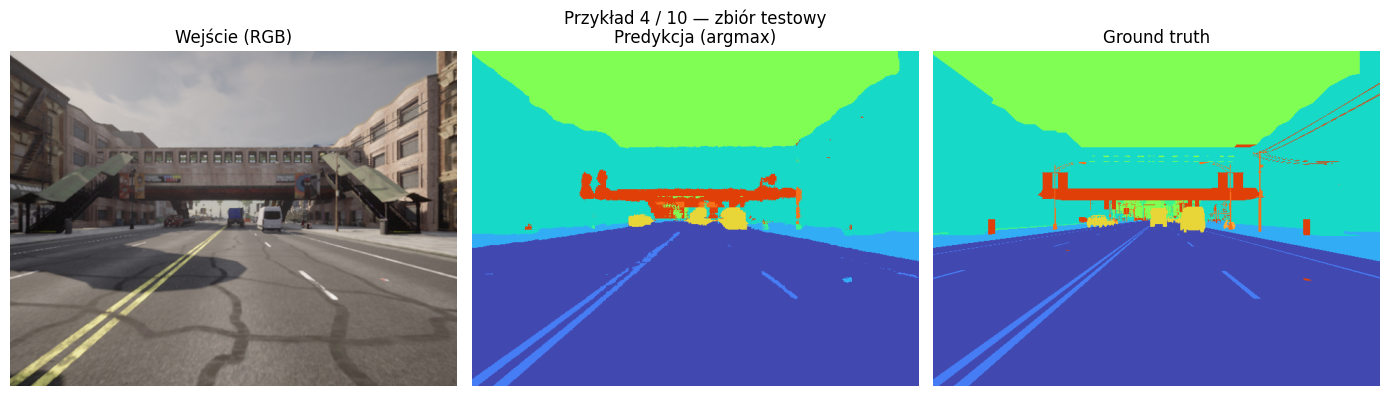

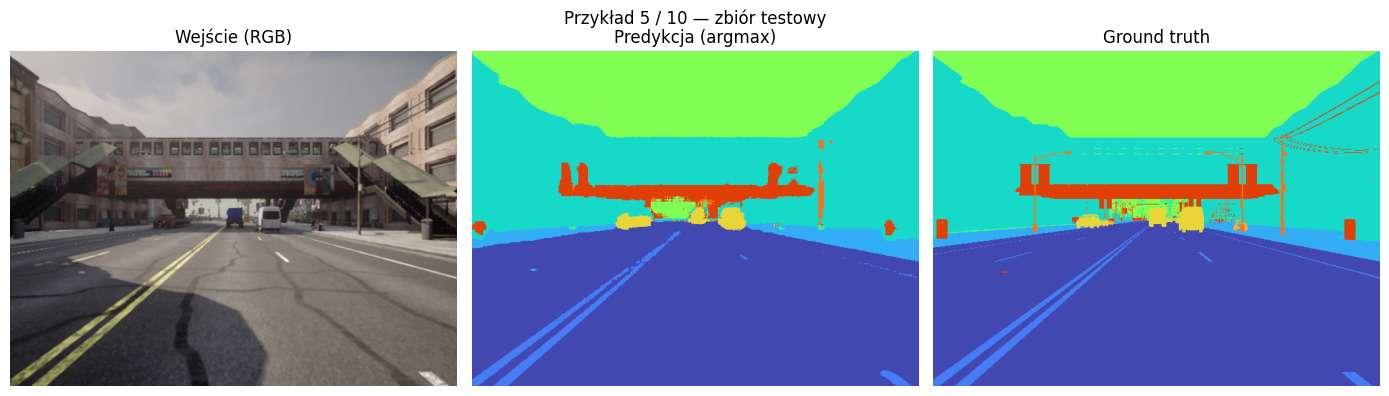

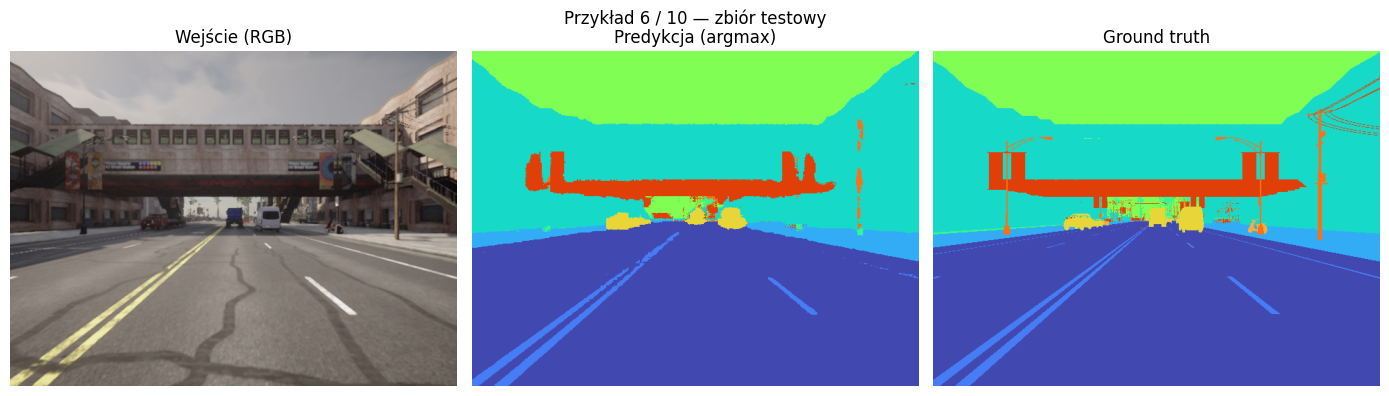

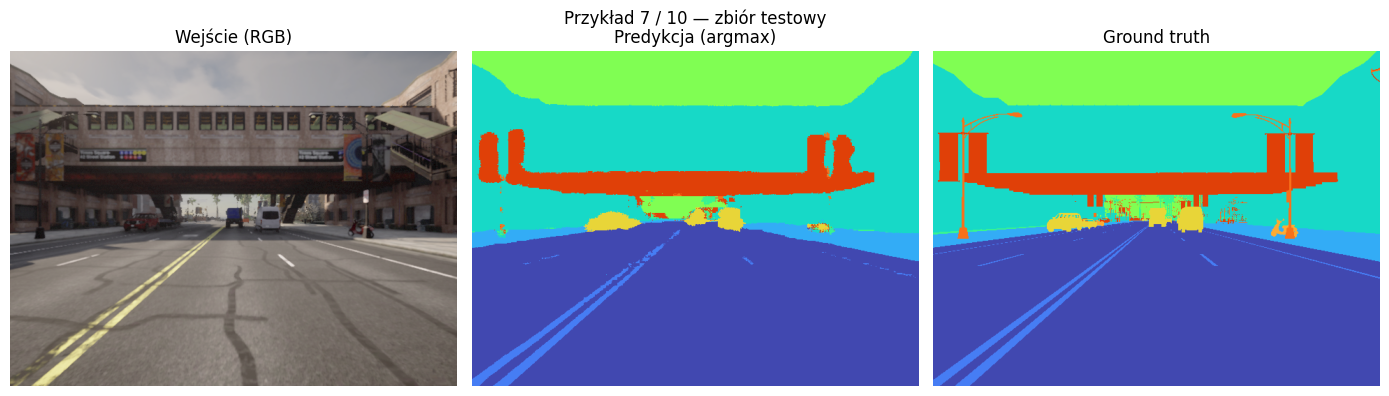

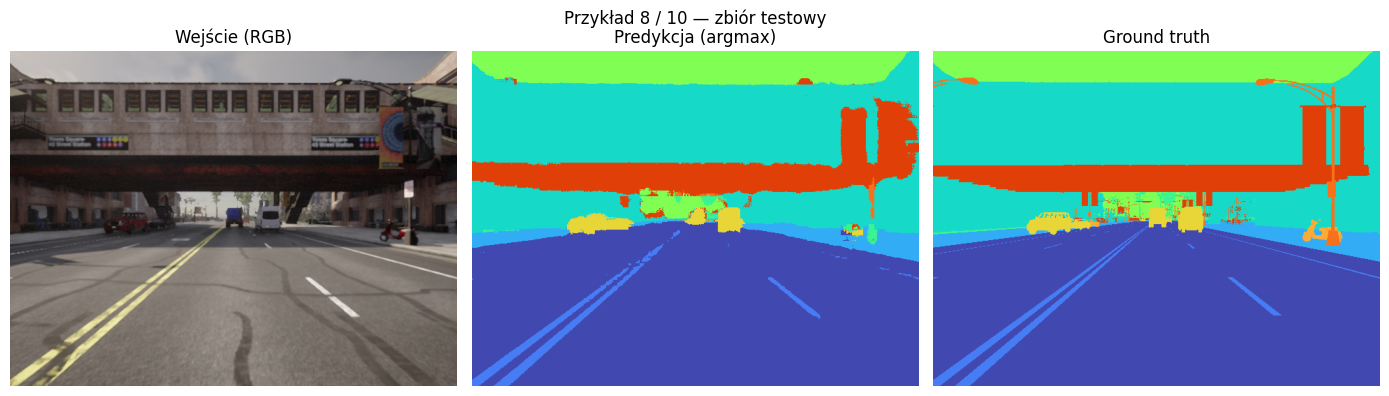

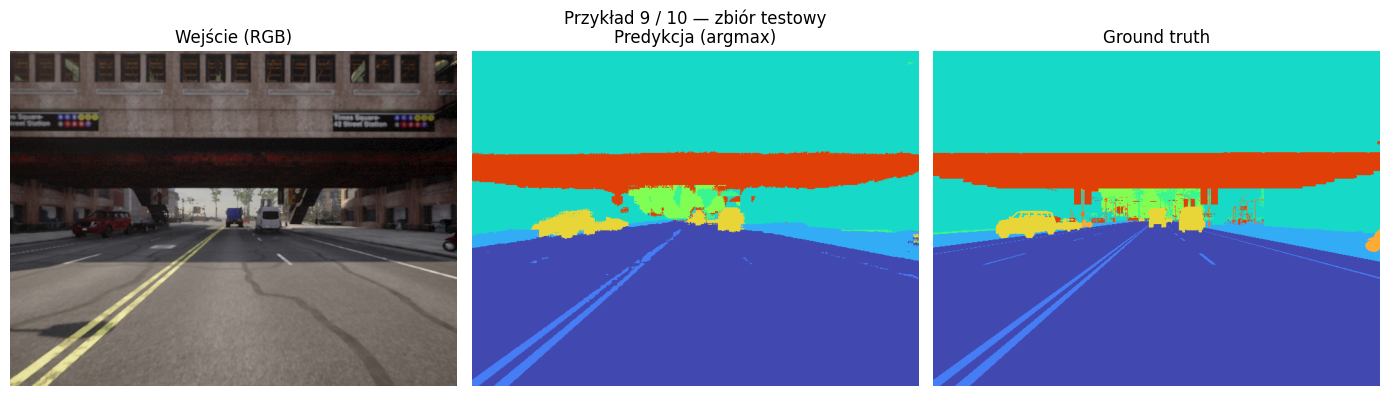

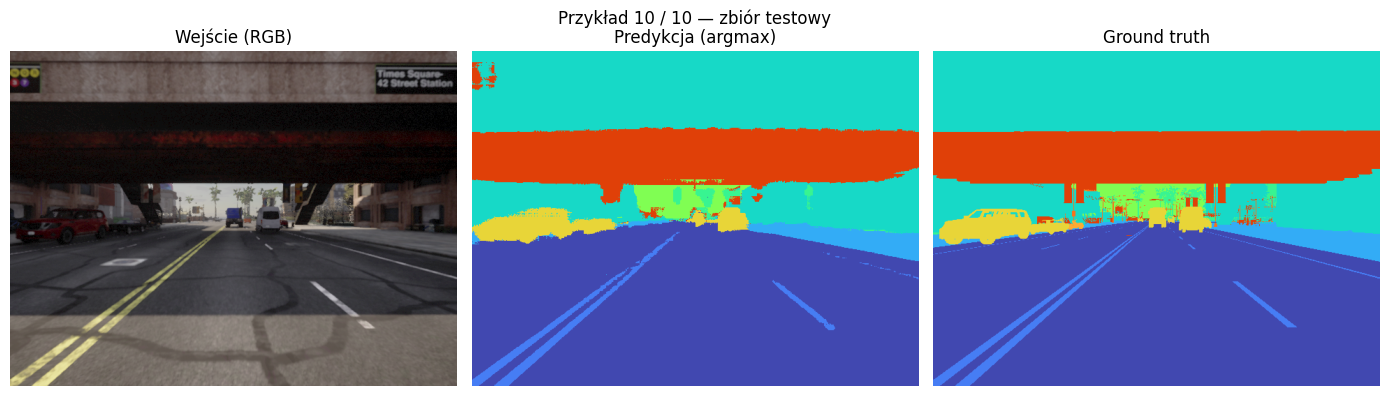

In [6]:
# Wizualizacja działania modelu (RGB | predykcja | GT)
# Wymaga: CONFIG, NUM_CLASSES, LABEL_LUT, SegModel, F, DataLoader, CARLADataset
# (komórki 1–4). Checkpoint z komórki treningowej lub sam plik .ckpt.

import matplotlib.pyplot as plt

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seg_demo = SegModel(
    num_classes=NUM_CLASSES,
    freeze_encoder=False,
).to(_device)
load_seg_weights_from_checkpoint(seg_demo, CONFIG["checkpoint_path"], _device)
seg_demo.eval()

try:
    _loader = test_loader
except NameError:
    _test_ds = CARLADataset(
        CONFIG["data_root"],
        LABEL_LUT,
        max_per_sequence=CONFIG["max_images_per_sequence"],
        sequences=CONFIG["test_sequences"],
    )
    _loader = DataLoader(_test_ds, batch_size=2, shuffle=False, num_workers=0)


def _idx_to_rgb(mask_hw, n_classes):
    lut = (plt.cm.turbo(np.linspace(0, 0.92, n_classes))[:, :3]).astype(np.float32)
    m = np.clip(mask_hw.detach().cpu().numpy(), 0, n_classes - 1)
    return lut[m]


N_SHOW = 10
_shown = 0

with torch.no_grad():
    for _imgs, _masks in _loader:
        _imgs = _imgs.to(_device)
        _logits = seg_demo(_imgs)
        _logits = F.interpolate(
            _logits,
            size=_masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        _pred = _logits.argmax(dim=1)
        for _b in range(_imgs.size(0)):
            if _shown >= N_SHOW:
                break
            _shown += 1
            _rgb = _imgs[_b].cpu().permute(1, 2, 0).numpy()
            _rgb = np.clip(_rgb, 0.0, 1.0)
            _fig, _ax = plt.subplots(1, 3, figsize=(14, 4))
            _ax[0].imshow(_rgb)
            _ax[0].set_title("Wejście (RGB)")
            _ax[0].axis("off")
            _ax[1].imshow(_idx_to_rgb(_pred[_b], NUM_CLASSES))
            _ax[1].set_title("Predykcja (argmax)")
            _ax[1].axis("off")
            _ax[2].imshow(_idx_to_rgb(_masks[_b], NUM_CLASSES))
            _ax[2].set_title("Ground truth")
            _ax[2].axis("off")
            _fig.suptitle(f"Przykład {_shown} / {N_SHOW} — zbiór testowy")
            plt.tight_layout()
            plt.show()
        if _shown >= N_SHOW:
            break

if _shown < N_SHOW:
    print(f"Uwaga: w zbiorze testowym jest tylko {_shown} próbek (pytano o {N_SHOW}).")
